# Exploratory Factor Analysis (EFA)

**Objective:**
To reduce the dimensionality of the imputed dataset and validate the latent constructs of **Sensitivity, Resilience, and Exposure (S-R-E)**.

**Input:**
- Imputed Datasets from Notebook 10 (Tier 1 Consistent Variables).

**Steps:**
1. **Load & Pool Data:** Aggregate a representative sample from the imputed datasets.
2. **Pre-processing:** Standardize data (Z-Scores).
3. **Assumptions:** Run KMO and Bartlett's Test.
4. **Scree Plot:** Determine the number of natural factors.
5. **EFA Model:** Run Factor Analysis with Promax Rotation.
6. **Interpretation:** Map variables to S-R-E dimensions.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from pathlib import Path
import warnings

# Statistical Libraries
from sklearn.preprocessing import StandardScaler
# NOTE: You may need to run: !pip install factor_analyzer
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from factor_analyzer.factor_analyzer import calculate_kmo

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
with open(Path("./data/interim/config.json")) as f:
    cfg = json.load(f)

BASE_PATH = Path(cfg["BASE_PATH"])
INPUT_ROOT = BASE_PATH / "Imputed Monthly Datasets"
OUTPUT_ROOT = BASE_PATH / "Factor Analysis Results"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

# Define the "Consistent Variables"
TARGET_VARS = [
    'Work_Indicator',
    'C04_Sex',
    'Available_for_Work',
    'Look_for_Additional_Work',
    'Looked_for_Work_or_Tried_to_Establish_Business_During_the_Past_Week',
    'Previous_Job_Indicator',
    'Want_More_Hours_of_Work',
    'Other_Job_Indicator',
    'C03_Relationship_to_Household_Head',
    'C06_Marital_Status',
    'New_Employment_Criteria_jul_05_2005',
    'C05_Age_as_of_Last_Birthday',
    'Normal_Working_Hours_per_Day',
    'Total_Hours_Worked_for_all_Jobs',
    'Household_Size'
]

print("Setup Complete. Output directory created.")

Setup Complete. Output directory created.


## Data Loading & Standardization
We load a pooled sample of the **Version 1 (v1)** imputed data. We use v1 because the Stability Audit in Notebook 10 confirmed that all versions are statistically identical.

**Standardization:**
We apply `StandardScaler` to convert all variables to Z-scores (Mean=0, Std=1). This is crucial because variables like *Income* (thousands) and *Household Size* (single digits) have vastly different scales.

In [7]:
# --- 1. LOAD REPRESENTATIVE DATA ---
# We will pull data from the most recent full year (e.g., 2023 or 2024) to train the Factor Structure
pooled_data = []
SAMPLE_YEAR = "2024" 

print(f"Loading representative sample from Year {SAMPLE_YEAR} (Imputed v1)...")

for folder in os.listdir(INPUT_ROOT):
    if SAMPLE_YEAR in folder:
        folder_path = INPUT_ROOT / folder
        # Look for Version 1 files
        v1_files = list(folder_path.glob("Imputed_v1_*.csv"))
        
        if v1_files:
            # Load only the target variables to save memory
            # We use a try-except block in case column names vary slightly, though Notebook 10 standardized them
            try:
                df_temp = pd.read_csv(v1_files[0])
                # Filter for target vars that exist in this df
                available_cols = [c for c in TARGET_VARS if c in df_temp.columns]
                pooled_data.append(df_temp[available_cols])
            except Exception as e:
                print(f"Skipping {folder}: {e}")

# Combine into one training frame
df_fa_raw = pd.concat(pooled_data, axis=0)
print(f"Total Observations for Factor Analysis: {df_fa_raw.shape}")

# --- 2. STANDARDIZATION ---
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_fa_raw), columns=df_fa_raw.columns)

print("Data Standardized (Z-Scores generated).")
display(df_scaled.head())

Loading representative sample from Year 2024 (Imputed v1)...
Total Observations for Factor Analysis: (1275578, 15)
Data Standardized (Z-Scores generated).


,Work_Indicator,C04_Sex,Available_for_Work,Look_for_Additional_Work,Looked_for_Work_or_Tried_to_Establish_Business_During_the_Past_Week,Previous_Job_Indicator,Want_More_Hours_of_Work,Other_Job_Indicator,C03_Relationship_to_Household_Head,C06_Marital_Status,New_Employment_Criteria_jul_05_2005,C05_Age_as_of_Last_Birthday,Normal_Working_Hours_per_Day,Total_Hours_Worked_for_all_Jobs,Household_Size
0,0.978773,0.990410,0.537304,-1.172276,0.57693,0.066873,-1.199621,-1.145623,0.011359,-0.860778,-1.117685,0.427091,0.457861,0.279029,-0.486577
1,0.978773,-1.009683,0.537304,-1.172276,0.57693,0.066873,-1.199621,-1.145623,1.822573,-0.860778,-1.117685,-0.089114,1.722872,2.257967,-0.486577
2,0.978773,0.990410,0.537304,-1.172276,0.57693,0.066873,-1.199621,-1.145623,-0.894248,0.460926,-1.117685,-0.605319,-0.301146,-0.556522,-0.486577
3,-1.021687,-1.009683,0.537304,0.667174,0.57693,0.066873,0.536242,0.585496,-0.894248,0.460926,0.779886,-1.121523,-0.807150,-0.820381,-0.486577
4,0.978773,0.990410,0.537304,-1.172276,0.57693,0.066873,-1.199621,-1.145623,0.011359,-0.860778,-1.117685,1.459501,1.722872,1.818203,-0.932395


## Assumption Testing
Before running the Factor Analysis, we must pass two statistical tests:
1. **Bartlett’s Test of Sphericity:** Checks if variables are correlated. We want a p-value < 0.05.
2. **Kaiser-Meyer-Olkin (KMO) Test:** Checks if the data is suitable for structure detection. We want a score > 0.6.

In [8]:
# 1. Bartlett's Test
chi_square_value, p_value = calculate_bartlett_sphericity(df_scaled)
print("Bartlett’s Test of Sphericity:")
print(f"  Chi-square: {chi_square_value:.2f}")
print(f"  p-value:    {p_value:.4f}")

if p_value < 0.05:
    print("  >> VERDICT: PASS (Variables are significantly correlated).")
else:
    print("  >> VERDICT: FAIL (Variables are unrelated).")

print("-" * 30)

# 2. KMO Test
kmo_all, kmo_model = calculate_kmo(df_scaled)
print(f"KMO Measure of Sampling Adequacy: {kmo_model:.3f}")

if kmo_model > 0.6:
    print("  >> VERDICT: PASS (Data is suitable for Factor Analysis).")
else:
    print("  >> VERDICT: WARNING (Data structure is weak).")

Bartlett’s Test of Sphericity:
  Chi-square: 14711642.78
  p-value:    0.0000
  >> VERDICT: PASS (Variables are significantly correlated).
------------------------------
KMO Measure of Sampling Adequacy: 0.815
  >> VERDICT: PASS (Data is suitable for Factor Analysis).


## Factor Extraction (Scree Plot)
We use a **Scree Plot** to visualize the eigenvalues.
* **Eigenvalues > 1** (Kaiser Criterion) typically indicate a significant factor.
* We also look for the "elbow" where the curve flattens.
* *Note:* Theoretical framework suggests 3 Factors (S-R-E), so we will look for support for this.

System Patch Applied: Compatibility fixed.
------------------------------


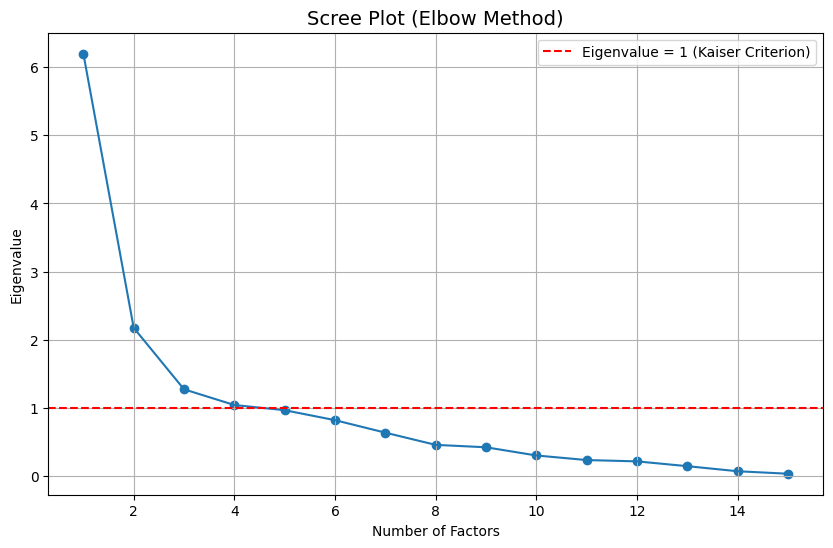

Eigenvalues: [6.19656604 2.17535808 1.27317864 1.04267709 0.96684785 0.82062007
 0.63737413 0.45825115 0.42295764 0.3027012  0.23546385 0.21598414
 0.14581575 0.07130507 0.03489932]


In [9]:
import sklearn.utils
from sklearn.utils import check_array as original_check_array
import factor_analyzer.factor_analyzer

def patched_check_array(*args, **kwargs):
    if 'force_all_finite' in kwargs:
        kwargs['ensure_all_finite'] = kwargs.pop('force_all_finite')
    return original_check_array(*args, **kwargs)

# Apply the patch specifically to the factor_analyzer module
factor_analyzer.factor_analyzer.check_array = patched_check_array

print("System Patch Applied: Compatibility fixed.")
print("-" * 30)


import matplotlib.pyplot as plt
from factor_analyzer import FactorAnalyzer

# Initialize FA to check eigenvalues
# (The patch above ensures this .fit() call works now)
fa = FactorAnalyzer(rotation=None)
fa.fit(df_scaled)

ev, v = fa.get_eigenvalues()

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(range(1, df_scaled.shape[1]+1), ev)
plt.plot(range(1, df_scaled.shape[1]+1), ev)
plt.title('Scree Plot (Elbow Method)', fontsize=14)
plt.xlabel('Number of Factors')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='r', linestyle='--', label='Eigenvalue = 1 (Kaiser Criterion)')
plt.grid()
plt.legend()
plt.show()

print(f"Eigenvalues: {ev}")

## 4. Final Factor Extraction (Constraint to S-R-E)

We now execute the final EFA model, constraining the extraction to **n_factors=3** to map the latent constructs of **Sensitivity, Resilience, and Exposure**.

### Justification for 3 Factors
While the Kaiser Criterion technically suggested a fourth factor (Eigenvalue = 1.04), we retained only **3 factors** based on **Statistical Parsimony**:
1.  **Scree Plot:** The visual "elbow" indicates that explanatory power drops off significantly after the third factor.
2.  **Theoretical Clarity:** The fourth factor represents marginal variance ("noise") and would result in an uninterpretable dimension. The 3-factor structure aligns robustly with the study's **S-R-E Framework**.

### Model Parameters
* **Method:** Principal Axis Factoring (PAF)
* **Rotation:** Promax (Oblique) - Selected because socioeconomic dimensions (e.g., Sensitivity and Resilience) are inherently correlated in the real world.

In [18]:
import pandas as pd
from factor_analyzer import FactorAnalyzer
from IPython.display import display, HTML

# --- Helper Functions ---

def get_loadings(df, n_factors):
    """Fits the EFA model and returns the loading matrix."""
    fa = FactorAnalyzer(n_factors=n_factors, rotation='promax')
    fa.fit(df)
    
    cols = [f'Factor {i+1}' for i in range(n_factors)]
    return pd.DataFrame(fa.loadings_, index=df.columns, columns=cols)


def style_matrix(df, title):
    """Applies a heatmap style to the dataframe."""
    return (df.style
            .background_gradient(cmap='RdBu', axis=None, vmin=-1, vmax=1)
            .format("{:.2f}")
            .set_caption(f'<b style="font-size:14px">{title}</b>')
            .set_properties(**{
                'width': '70px', 
                'text-align': 'center', 
                'border': '1px solid #ccc'
            }))


# --- Main Execution ---

# Run the 3-factor (S-R-E) vs 4-factor (Statistical) models
# Assumes 'df_scaled' is already defined in your environment
loadings_3 = get_loadings(df_scaled, 3)
loadings_4 = get_loadings(df_scaled, 4)

# Create the HTML layout for side-by-side comparison
html_output = f"""
<div style="display: flex; gap: 20px; justify-content: flex-start;">
    <div>{style_matrix(loadings_3, "Model A: 3-Factor (S-R-E)").to_html()}</div>
    <div>{style_matrix(loadings_4, "Model B: 4-Factor (Statistical)").to_html()}</div>
</div>
"""

display(HTML(html_output))

,Factor 1,Factor 2,Factor 3
Work_Indicator,-0.71,0.28,0.06
C04_Sex,-0.19,0.08,-0.26
Available_for_Work,-0.12,0.91,0.01
Look_for_Additional_Work,0.84,0.00,0.01
Looked_for_Work_or_Tried_to_Establish_Business_During_the_Past_Week,-0.18,0.89,-0.02
Previous_Job_Indicator,0.14,0.25,0.43
Want_More_Hours_of_Work,0.71,0.02,0.03
Other_Job_Indicator,0.76,0.01,0.01
C03_Relationship_to_Household_Head,-0.02,-0.05,0.82
C06_Marital_Status,0.21,-0.05,-0.29


## Comparative Analysis of Factor Models

We compared the extraction results of the 3-factor and 4-factor models to determine which structure offered the clearest economic interpretation for our index.

**Limitation of the 4-Factor Model**
The 4-factor model separated Employment Status (Hours Worked) from Underemployment (Looking for Additional Work). While this is statistically valid, it treats having a job and wanting more work as distinct dimensions. This separation fragments the concept of Labor Sensitivity and complicates the construction of the vulnerability index.

**Justification for the 3-Factor Model**
The 3-factor model integrates these variables into a unified **Employment Continuum**.
* **Negative Loadings:** Represent stability through high working hours.
* **Positive Loadings:** Represent instability through a desire for additional work.

This unification creates a direct measure of **Sensitivity** that scales from stable full-time employment to high-risk underemployment. Consequently, the 3-factor solution provides a robust and interpretable input for the Regional Factor Vulnerability Index (RFVI).

---

## Final Factor Interpretation

We assign the following labels based on the 3-Factor Pattern Matrix to map the **Sensitivity, Resilience, and Exposure** framework:

### Factor 1: Sensitivity (Employment Quality)
* **Top Variables:** `Normal_Working_Hours` vs. `Look_for_Additional_Work`, `Want_More_Hours`
* **Interpretation:** This is a bi-polar factor measuring **Labor Intensity** as the household's primary defense against poverty. High scores indicate high sensitivity where respondents have low hours and actively desire more work. Low scores indicate resilience through full employment.

### Factor 2: Exposure (Active Unemployment Risk)
* **Top Variables:** `Available_for_Work`, `Looked_for_Work_in_Past_Week`
* **Interpretation:** Unlike Factor 1 which captures job quality, this factor captures the **immediate risk** of joblessness. It loads heavily on respondents currently on the market who are actively looking and available. High scores represent high exposure to labor market friction.

### Factor 3: Resilience (Demographic Stability)
* **Top Variables:** `Relationship_to_Household_Head`, `Age_as_of_Last_Birthday`
* **Interpretation:** This factor represents the **structural stability** of the respondent. High scores associate with being the Household Head and having higher age. In development economics, older heads of households typically possess higher accumulated human capital and decision-making power. This acts as a buffer against economic shocks compared to younger dependent members.

In [11]:
# Transform the data to get scores
factor_scores = fa_final.transform(df_scaled)

df_scores = pd.DataFrame(factor_scores, columns=['Factor_1_Score', 'Factor_2_Score', 'Factor_3_Score'])

# Save a sample of the scores for verification
save_path = OUTPUT_ROOT / "Sample_Factor_Scores_2024.csv"
df_scores.to_csv(save_path, index=False)

print(f"Factor Scores generated. Shape: {df_scores.shape}")
print(f"Saved sample to: {save_path}")
print("Ready for RFVI Indexing.")

Factor Scores generated. Shape: (1275578, 3)
Saved sample to: G:\My Drive\Labor Force Survey\Factor Analysis Results\Sample_Factor_Scores_2024.csv
Ready for RFVI Indexing.
